In [35]:
from pathlib import Path
import json

# Find the root directory, no matter where we are. 
def find_project_root(marker="README.md"):
    p = Path.cwd()
    while p != p.parent:
        if (p / marker).exists():
            return p
        p = p.parent
    raise RuntimeError("Project root not found")

PROJECT_ROOT = find_project_root()

path = PROJECT_ROOT / "notebooks/api_progress.json"

In [36]:
# Read in feature engineered data 

input_path = PROJECT_ROOT / "data/processed/feature_engineered_data.csv"
import pandas as pd
df = pd.read_csv(input_path)

In [37]:
df['title'] = df['title'].fillna('')
df['description'] = df['description'].fillna('')

In [38]:
df['title_description'] = df['title'] + ' ' + df['description']

In [39]:
df['missing_long_lat'] = df['longitude'].isna() | df['latitude'].isna()

In [40]:
company_counts = df['company.display_name'].value_counts()
df['company_listing_count'] = df['company.display_name'].map(company_counts)

In [41]:
min_count = 50  # tune this threshold

for col in ['location_region', 'location_city']:
    counts = df[col].value_counts()
    df[col] = df[col].where(df[col].map(counts) >= min_count, 'Other')

In [42]:
# Remove rows with salaries below 50k and cap salaries above 300k. We've found that there's a lot of data entry errors (like 20 and 40) below the 50k mark. 

lower = 50_000
upper = 300_000

df = df[df['avg_salary'] >= lower].copy()
df['avg_salary'] = df['avg_salary'].clip(upper=upper)

In [43]:
experiments = [
    {'text': 'title',    'features': 'tfidf',       'reduce': False},
    {'text': 'title_description',      'features': 'tfidf',       'reduce': True},
    {'text': 'title',    'features': 'embeddings',  'reduce': False},
    {'text': 'title',    'features': 'embeddings',  'reduce': True},
    {'text': 'title_description',      'features': 'embeddings',  'reduce': False},
    {'text': 'title_description',      'features': 'tfidf',  'reduce': False}# ,
    # Removed this as computationally expensive to run (takes more than 5 minutes per fold) 
    # and we already know that reduce on description + no reduce on title is better than reduce on both. 
    # {'text': 'title_description',      'features': 'both',        'reduce': True},
    # add others if early results suggest they're interesting
]

In [44]:
pd.DataFrame(experiments)

,text,features,reduce
0,title,tfidf,False
1,title_description,tfidf,True
2,title,embeddings,False
3,title,embeddings,True
4,title_description,embeddings,False
5,title_description,tfidf,False


In [45]:
X_structured = df.drop(columns=['avg_salary', 'title', 'description'])
X_structured.columns

cat_vars = ['contract_type', 'contract_time', 'category.label', 'location.area_length', 
            # 'location_country', 
            'location_state', 'location_region', 'location_city', 'missing_long_lat']

num_vars = ['longitude', 'latitude', 'company_listing_count']

In [46]:
# df[num_vars].apply(lambda x: type(x[0]))

In [47]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
from sklearn.impute import SimpleImputer

df = df.reset_index(drop=True)
y = df['avg_salary'].values

# encode categoricals
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[cat_vars])


imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# scale continuous
cont_imputed = imputer.fit_transform(df[num_vars])
cont_scaled = scaler.fit_transform(cont_imputed)


# combine into one non-text feature matrix
X_structured = np.hstack([cat_encoded, cont_scaled])

In [12]:
nan_cols = np.where(np.isnan(X_structured).any(axis=0))[0]
print(nan_cols)

[]


In [13]:
# Model training and validation functions 

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sentence_transformers import SentenceTransformer
import pandas as pd

EMBEDDING_MODEL = SentenceTransformer('all-MiniLM-L6-v2')


def get_text_series(df, text_config):
    """
    Select the appropriate text column from the dataframe.
    text_config: 'title', 'description', or 'title_description'
    """
    valid = ['title', 'description', 'title_description']
    if text_config not in valid:
        raise ValueError(f"text_config must be one of {valid}, got '{text_config}'")
    return df[text_config]


def build_text_features(train_series, val_series, feature_config, reduce=False, n_components=100):
    """
    Fit text transformers on train_series, transform both train and val.
    feature_config: 'tfidf', 'embeddings', or 'both'
    Returns X_train, X_val as numpy arrays.
    """

    def get_tfidf(train, val):
        tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
        X_train = tfidf.fit_transform(train)
        X_val = tfidf.transform(val)
        if reduce:
            svd = TruncatedSVD(n_components=n_components, random_state=42)
            X_train = svd.fit_transform(X_train)
            X_val = svd.transform(X_val)
        else:
            X_train = X_train.toarray()
            X_val = X_val.toarray()
        return X_train, X_val

    def get_embeddings(train, val):
        X_train = EMBEDDING_MODEL.encode(train.tolist(), batch_size=64, show_progress_bar=False)
        X_val = EMBEDDING_MODEL.encode(val.tolist(), batch_size=64, show_progress_bar=False)
        if reduce:
            pca = PCA(n_components=n_components, random_state=42)
            X_train = pca.fit_transform(X_train)
            X_val = pca.transform(X_val)
        return X_train, X_val

    if feature_config == 'tfidf':
        return get_tfidf(train_series, val_series)
    elif feature_config == 'embeddings':
        return get_embeddings(train_series, val_series)
    elif feature_config == 'both':
        tfidf_train, tfidf_val = get_tfidf(train_series, val_series)
        emb_train, emb_val = get_embeddings(train_series, val_series)
        return np.hstack([tfidf_train, emb_train]), np.hstack([tfidf_val, emb_val])
    else:
        raise ValueError(f"feature_config must be 'tfidf', 'embeddings', or 'both', got '{feature_config}'")


def evaluate(y_true, y_pred):
    """
    Calculate regression metrics.
    Returns dict with rmse, mae, r2.
    """
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred)
    }


def run_experiments(df, X_structured, y, experiments, use = 'both', n_splits=5, model_type='ridge'):
    """
    Run each experiment config across k folds, average metrics, return results dataframe.
    df: full dataframe containing text columns
    X_structured: pre-encoded non-text features as numpy array (n_samples, n_features)
    y: target array (n_samples,)
    experiments: list of dicts with keys 'text', 'features', 'reduce'
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []

    for exp in experiments:
        print(f"Running: {exp}")
        fold_metrics = []

        for fold_num, (train_idx, val_idx) in enumerate(kf.split(df)):
            # Print statement so we can track progress more granularly
            print(f"  Fold {fold_num + 1}/{n_splits}")
            # slice text
            text_series = get_text_series(df, exp['text'])
            train_text = text_series.iloc[train_idx]
            val_text = text_series.iloc[val_idx]

            # build text features
            X_text_train, X_text_val = build_text_features(
                train_text, val_text,
                feature_config=exp['features'],
                reduce=exp['reduce']
            )

            # slice and combine with non-text features
            
            if use == 'text':
                X_train = X_text_train
                X_val = X_text_val
            elif use == 'structured':
                X_train = X_structured[train_idx]
                X_val = X_structured[val_idx]
            elif use == 'both':
                X_train = np.hstack([X_text_train, X_structured[train_idx]])
                X_val = np.hstack([X_text_val, X_structured[val_idx]])
            else:
                raise ValueError(f"use must be 'text', 'structured', or 'both', got '{use}'")

            y_train = y[train_idx]
            y_val = y[val_idx]

            # fit model
            model = Ridge(alpha=1.0) if model_type == 'ridge' else Lasso(alpha=0.1)
            model.fit(X_train, y_train)

            # evaluate
            y_pred = model.predict(X_val)
            fold_metrics.append(evaluate(y_val, y_pred))

        # average across folds
        avg_metrics = {k: np.mean([f[k] for f in fold_metrics]) for k in fold_metrics[0]}
        results.append({**exp, **avg_metrics})

    return pd.DataFrame(results)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
results = run_experiments(df, X_structured, y, experiments, n_splits=5, model_type='ridge')

Running: {'text': 'title', 'features': 'tfidf', 'reduce': False}
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Running: {'text': 'title_description', 'features': 'tfidf', 'reduce': True}
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Running: {'text': 'title', 'features': 'embeddings', 'reduce': False}
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Running: {'text': 'title', 'features': 'embeddings', 'reduce': True}
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Running: {'text': 'title_description', 'features': 'embeddings', 'reduce': False}
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Running: {'text': 'title_description', 'features': 'tfidf', 'reduce': False}
  Fold 1/5


In [ ]:
experiments[0]

{'text': 'title', 'features': 'tfidf', 'reduce': False}

In [1]:
results_text = run_experiments(df, X_structured, y, experiments, use='text', n_splits=5, model_type='ridge')
results_structured = run_experiments(df, X_structured, y, [experiments[0]], use='structured', n_splits=5, model_type='ridge')

NameError: name 'run_experiments' is not defined

<Figure size 1200x600 with 0 Axes>

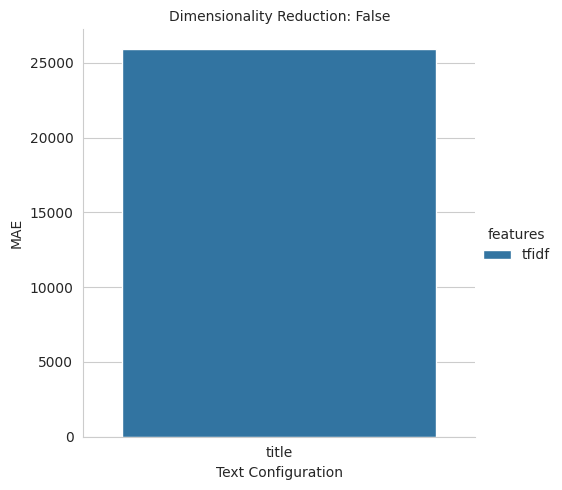

In [ ]:
# Plot RSME as a function of text, features, and reduce 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
# sns.barplot(data=results, x='text', y='rmse', hue='features')
# plt.title('RMSE by Text Configuration and Feature Type')
# plt.ylabel('RMSE')
# plt.xlabel('Text Configuration')
# plt.legend(title='Feature Type')
# Facet by reduce 
g = sns.catplot(data=results, x='text', y='mae', hue='features', col='reduce', kind='bar', height=5, aspect=1)
g.set_axis_labels("Text Configuration", "MAE")
g.set_titles("Dimensionality Reduction: {col_name}")
plt.show()

<Figure size 1200x600 with 0 Axes>

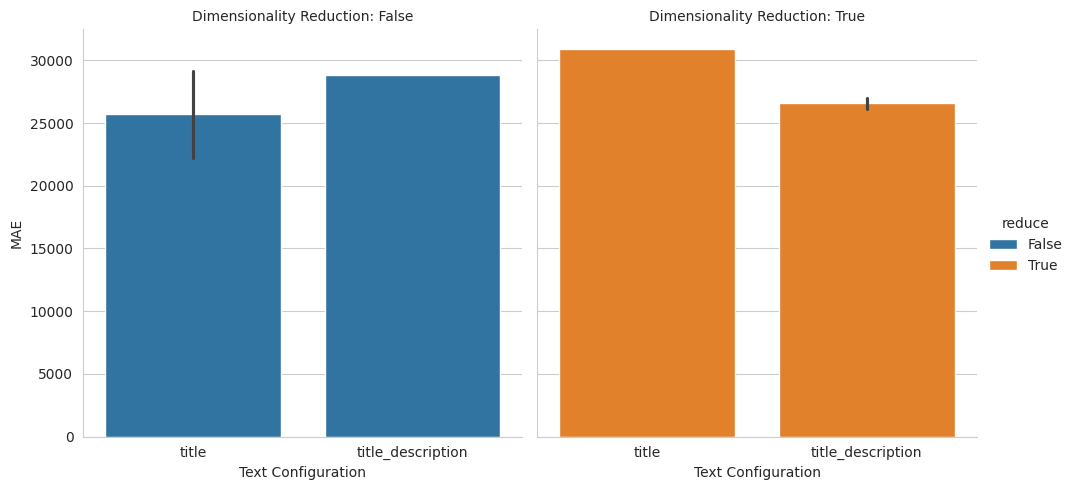

In [93]:
# Plot predictive power of a text only model
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))
g = sns.catplot(data=results_text, x='text', y='mae', hue='reduce', col='reduce', kind='bar', height=5, aspect=1)
g.set_axis_labels("Text Configuration", "MAE")
g.set_titles("Dimensionality Reduction: {col_name}")
plt.show()

In [47]:
# Get the median salary from out data 
median_salary = df['avg_salary'].median()
print(median_salary)

93600.0


In [50]:
df['title'].str.lower().value_counts()

title
occupational therapist                                      136
registered nurse                                            104
speech pathologist                                           95
early childhood teacher                                      65
project manager                                              57
                                                           ... 
seeking casual disability support workers in wangaratta!      1
wanted: experienced disability workers in wodonga             1
group / state financial controller (ac8161)                   1
gp practice receptionist                                      1
assistant practice manager                                    1
Name: count, Length: 9762, dtype: int64

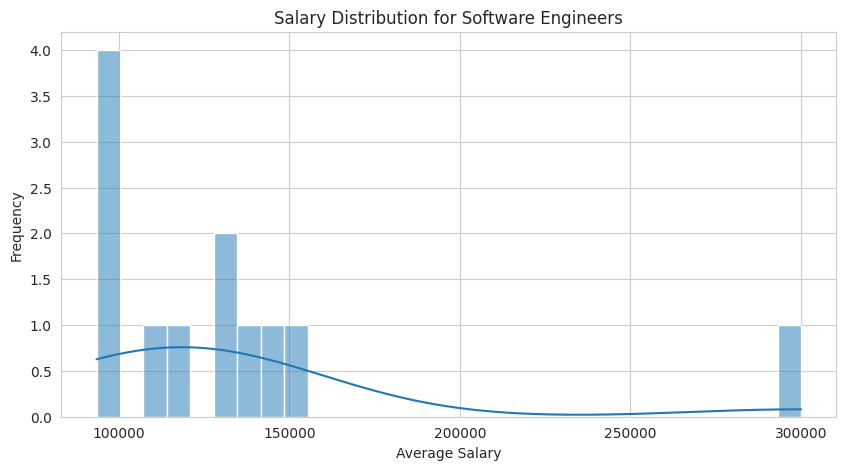

In [91]:
# Plot the salary distribution jsut for 'Software Engineer' 
plt.figure(figsize=(10, 5))
sns.histplot(df[df['title'].str.lower() == 'software engineer']['avg_salary'], bins=30, kde=True)
plt.title('Salary Distribution for Software Engineers')
plt.xlabel('Average Salary')
plt.ylabel('Frequency')
plt.show()

In [100]:
results_text

,text,features,reduce,rmse,mae,r2
0,title,tfidf,False,33415.214148,22248.865206,0.630034
1,title_description,tfidf,True,38872.149867,27032.877291,0.499389
2,title,embeddings,False,40730.356962,29160.168245,0.450516
3,title,embeddings,True,42885.880743,30925.780836,0.390936
4,title_description,embeddings,False,39888.936501,28797.368268,0.473068
5,title_description,both,True,37157.710735,26122.319676,0.542711


In [32]:
# Text the performance of a mdoel that reduces description but not title: 
n_splits = 5
use = 'text'
model_type = 'ridge'

kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
results = []


fold_metrics = []

for fold_num, (train_idx, val_idx) in enumerate(kf.split(df)):
    # Print statement so we can track progress more granularly
    print(f"  Fold {fold_num + 1}/{n_splits}")
    # slice text
    title_series = get_text_series(df, 'title')
    description_series = get_text_series(df, 'description')
    
    train_title_text = title_series.iloc[train_idx]
    val_title_text = title_series.iloc[val_idx]
    train_description_text = description_series.iloc[train_idx]
    val_description_text = description_series.iloc[val_idx]

    # build text features
    X_title_train, X_title_val = build_text_features(
        train_title_text, val_title_text,
        feature_config='tfidf',
        reduce= False 
    )
    
    X_description_train, X_description_val = build_text_features(
        train_description_text, val_description_text,
        feature_config='tfidf',
        reduce= True
    )

    # slice and combine with non-text features
    
    if use == 'text':
        X_train = np.hstack([X_title_train, X_description_train])
        X_val = np.hstack([X_title_val, X_description_val])
    elif use == 'structured':
        X_train = X_structured[train_idx]
        X_val = X_structured[val_idx]
    elif use == 'both':
        X_train = np.hstack([X_title_train, X_description_train, X_structured[train_idx]])
        X_val = np.hstack([X_title_val, X_description_val, X_structured[val_idx]])
    else:
        raise ValueError(f"use must be 'text', 'structured', or 'both', got '{use}'")

    y_train = y[train_idx]
    y_val = y[val_idx]

    # fit model
    model = Ridge(alpha=1.0) if model_type == 'ridge' else Lasso(alpha=0.1)
    model.fit(X_train, y_train)

    # evaluate
    y_pred = model.predict(X_val)
    fold_metrics.append(evaluate(y_val, y_pred))

print(fold_metrics)

  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
[{'rmse': np.float64(29423.442055121766), 'mae': 20679.142017283255, 'r2': 0.7050979722788047}, {'rmse': np.float64(32240.314718620506), 'mae': 21306.81324046477, 'r2': 0.6651518937255694}, {'rmse': np.float64(31634.93808216414), 'mae': 21392.29220600026, 'r2': 0.6546374606016248}, {'rmse': np.float64(32679.25054138652), 'mae': 21802.585094097074, 'r2': 0.6449601122289026}, {'rmse': np.float64(32304.671698925486), 'mae': 21961.91057009617, 'r2': 0.6699256364139152}]


In [34]:
# get feature names
ohe_feature_names = ohe.get_feature_names_out(cat_vars)
feature_names = list(ohe_feature_names) + num_vars

# retrain on full dataset
model = Ridge(alpha=1.0)
model.fit(X_structured, y)

# build importance dataframe
importances = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(importances.head(30))

                                          feature   coefficient
96                   location_city_Port Macquarie -59628.443288
71          location_region_Port Macquarie Region  52857.261241
19                         category.label_IT Jobs  38082.939606
17       category.label_Healthcare & Nursing Jobs  37460.176082
13          category.label_Energy, Oil & Gas Jobs  34113.063726
20                      category.label_Legal Jobs  30969.829973
41    location_state_Australian Capital Territory  28925.243012
28                     category.label_Retail Jobs -25181.564325
97                     location_city_Port Phillip  24831.358271
63                 location_region_Ipswich Region -24301.364677
12   category.label_Domestic help & Cleaning Jobs -23033.085259
22                category.label_Maintenance Jobs -22799.136470
18     category.label_Hospitality & Catering Jobs -21247.534153
56                  location_region_Darwin Region  21110.653049
43              location_state_Northern 